# Baseline models

In [99]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
import xgboost as xgb
import joblib

In [100]:
df = pd.read_csv('../../data/clean/full_data.csv')

In [101]:
df.drop(columns = ["rr"], inplace = True)
df.drop(columns = ["clasi_rr"], inplace = True)
df.drop(columns = ["clasi_rr_no_0"], inplace = True)
df.drop(columns = ["tmax_mean"], inplace = True)
df.drop(columns = ["tmin_mean"], inplace = True)
df.drop(columns = ["temp_prom"], inplace = True)
df.drop(columns = ["precip_total"], inplace = True)
df.drop(columns = ["precip_max"], inplace = True)
df.drop(columns = ["precip_min"], inplace = True)
df.drop(columns = ["precip_median"], inplace = True)
df.drop(columns = ["precip_mean"], inplace = True)
df.drop(columns = ["ndvi"], inplace = True)
df.drop(columns = ["aedes_aegypti"], inplace = True)
df.drop(columns = ["criaderos_de_mosquito"], inplace = True)
df.drop(columns = ["fiebre"], inplace = True)
df.drop(columns = ["plaquetas"], inplace = True)
df.drop(columns = ["buscar_trabajo"], inplace = True)
df.drop(columns = ["desempleo"], inplace = True)
df.drop(columns = ["empleo"], inplace = True)
df.drop(columns = ["comprar_carro"], inplace = True)
df.drop(columns = ["préstamo"], inplace = True)
df.drop(columns = ["tiquetes_avion"], inplace = True)
df.drop(columns = ["vacaciones"], inplace = True)
df.drop(columns = ["corte_agua"], inplace = True)
df.drop(columns = ["corte_de_agua"], inplace = True)
df.drop(columns = ["suspension_de_agua"], inplace = True)
df.drop(columns = ["dengue"], inplace = True)
df.drop(columns = ["nino34ssta"], inplace = True)

In [102]:
for i in range(5, 9):
    df.drop(columns = [f"casos_lag_{i}"], inplace = True)
    df.drop(columns = [f"tmax_mean_lag_{i}"], inplace = True)
    df.drop(columns = [f"tmin_mean_lag_{i}"], inplace = True)
    df.drop(columns = [f"temp_prom_lag_{i}"], inplace = True)
    df.drop(columns = [f"precip_total_lag_{i}"], inplace = True)
    df.drop(columns = [f"precip_max_lag_{i}"], inplace = True)
    df.drop(columns = [f"precip_min_lag_{i}"], inplace = True)
    df.drop(columns = [f"precip_median_lag_{i}"], inplace = True)
    df.drop(columns = [f"precip_mean_lag_{i}"], inplace = True)
    df.drop(columns = [f"ndvi_lag_{i}"], inplace = True)
    df.drop(columns = [f"nino34ssta_lag_{i}"], inplace = True)
    df.drop(columns = [f"aedes_aegypti_lag_{i}"], inplace = True)
    df.drop(columns = [f"criaderos_de_mosquito_lag_{i}"], inplace = True)
    df.drop(columns = [f"fiebre_lag_{i}"], inplace = True)
    df.drop(columns = [f"plaquetas_lag_{i}"], inplace = True)
    df.drop(columns = [f"buscar_trabajo_lag_{i}"], inplace = True)
    df.drop(columns = [f"desempleo_lag_{i}"], inplace = True)
    df.drop(columns = [f"empleo_lag_{i}"], inplace = True)
    df.drop(columns = [f"comprar_carro_lag_{i}"], inplace = True)
    df.drop(columns = [f"préstamo_lag_{i}"], inplace = True)
    df.drop(columns = [f"tiquetes_avion_lag_{i}"], inplace = True)
    df.drop(columns = [f"vacaciones_lag_{i}"], inplace = True)
    df.drop(columns = [f"corte_agua_lag_{i}"], inplace = True)
    df.drop(columns = [f"corte_de_agua_lag_{i}"], inplace = True)
    df.drop(columns = [f"suspension_de_agua_lag_{i}"], inplace = True)
    df.drop(columns = [f"dengue_lag_{i}"], inplace = True)

In [103]:
df.drop(columns = ["rr_lag_1"], inplace = True)
df.drop(columns = ["clasi_rr_lag_1"], inplace = True)
df.drop(columns = ["clasi_rr_no_0_lag_1"], inplace = True)
df.drop(columns = ["rr_lag_2"], inplace = True)
df.drop(columns = ["clasi_rr_lag_2"], inplace = True)
df.drop(columns = ["clasi_rr_no_0_lag_2"], inplace = True)
df.drop(columns = ["rr_lag_3"], inplace = True)
df.drop(columns = ["clasi_rr_lag_3"], inplace = True)
df.drop(columns = ["clasi_rr_no_0_lag_3"], inplace = True)
df.drop(columns = ["rr_lag_4"], inplace = True)
df.drop(columns = ["clasi_rr_lag_4"], inplace = True)
df.drop(columns = ["clasi_rr_no_0_lag_4"], inplace = True)
df.drop(columns = ["rr_lag_5"], inplace = True)
df.drop(columns = ["clasi_rr_lag_5"], inplace = True)
df.drop(columns = ["clasi_rr_no_0_lag_5"], inplace = True)
df.drop(columns = ["rr_lag_6"], inplace = True)
df.drop(columns = ["clasi_rr_lag_6"], inplace = True)
df.drop(columns = ["clasi_rr_no_0_lag_6"], inplace = True)
df.drop(columns = ["rr_lag_7"], inplace = True)
df.drop(columns = ["clasi_rr_lag_7"], inplace = True)
df.drop(columns = ["clasi_rr_no_0_lag_7"], inplace = True)
df.drop(columns = ["rr_lag_8"], inplace = True)
df.drop(columns = ["clasi_rr_lag_8"], inplace = True)
df.drop(columns = ["clasi_rr_no_0_lag_8"], inplace = True)

In [104]:
df.head()

,casos,week_canton,urb,casos_lag_4,casos_lag_3,casos_lag_2,casos_lag_1,ndvi_lag_4,ndvi_lag_3,ndvi_lag_2,...,precip_mean_lag_2,precip_mean_lag_1,precip_median_lag_4,precip_median_lag_3,precip_median_lag_2,precip_median_lag_1,precip_min_lag_4,precip_min_lag_3,precip_min_lag_2,precip_min_lag_1
0,4,2020-9-101,1,0,2,5,3,0.471457,0.445589,0.446709,...,0.000000,0.528162,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2020-10-101,1,2,5,3,4,0.445589,0.446709,0.444844,...,0.528162,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2020-11-101,1,5,3,4,2,0.446709,0.444844,0.428539,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,2020-12-101,1,3,4,2,2,0.444844,0.428539,0.411972,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,2020-13-101,1,4,2,2,0,0.428539,0.411972,0.356043,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [105]:
df.shape

(24928, 107)

In [106]:
df = pd.get_dummies(df, columns = ["urb"])


In [107]:
df.head()

,casos,week_canton,casos_lag_4,casos_lag_3,casos_lag_2,casos_lag_1,ndvi_lag_4,ndvi_lag_3,ndvi_lag_2,ndvi_lag_1,...,precip_median_lag_3,precip_median_lag_2,precip_median_lag_1,precip_min_lag_4,precip_min_lag_3,precip_min_lag_2,precip_min_lag_1,urb_0,urb_1,urb_2
0,4,2020-9-101,0,2,5,3,0.471457,0.445589,0.446709,0.444844,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False
1,2,2020-10-101,2,5,3,4,0.445589,0.446709,0.444844,0.428539,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False
2,2,2020-11-101,5,3,4,2,0.446709,0.444844,0.428539,0.411972,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False
3,0,2020-12-101,3,4,2,2,0.444844,0.428539,0.411972,0.356043,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False
4,0,2020-13-101,4,2,2,0,0.428539,0.411972,0.356043,0.289130,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False,True,False


In [108]:
train = df[df['week_canton'] < '2024-1-101']
val = df[(df['week_canton'] >= '2024-1-101') & (df['week_canton'] < '2025-1-101')]
test = df[df['week_canton'] >= '2025-1-101']

X_train = train.drop(columns = ["casos", "week_canton"])
y_train = train['casos']

X_val = val.drop(columns = ["casos", "week_canton"])
y_val= val['casos']

X_test= test.drop(columns = ["casos", "week_canton"])
y_test = test['casos']

In [109]:
scaler = StandardScaler()  

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)  
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [110]:
X_test_for_reg = pd.concat([X_val, X_test], axis=0)
y_test_for_reg = pd.concat([y_val, y_test], axis=0)
val_test = pd.concat([val, test], axis=0)

X_test_for_reg_scaled = pd.DataFrame(scaler.transform(X_test_for_reg), columns=X_test_for_reg.columns)

In [111]:
train.shape, val.shape, test.shape

((16400, 109), (4264, 109), (4264, 109))

## Case number
### Linear regression

In [112]:
reg = LinearRegression().fit(X_train_scaled, y_train)

y_pred_reg = reg.predict(X_test_for_reg_scaled)

In [113]:
results_reg = pd.DataFrame({
    'actual': y_test_for_reg,   
    'pred': y_pred_reg, 
    "week_canton": val_test["week_canton"].values
})

results_reg.to_csv('../../data/model_results/results_cases_reg_inmediato.csv')

In [114]:
r2_reg = r2_score(y_test_for_reg, y_pred_reg)
mae_reg = mean_absolute_error(y_test_for_reg, y_pred_reg)
rmse_reg = root_mean_squared_error(y_test_for_reg, y_pred_reg)

In [115]:
print(f"""R2 reg: {round(r2_reg, 3)}
MAE reg: {round(mae_reg, 3)}
RMSE reg: {round(rmse_reg, 3)}
      """)

R2 reg: 0.894
MAE reg: 1.937
RMSE reg: 4.78
      


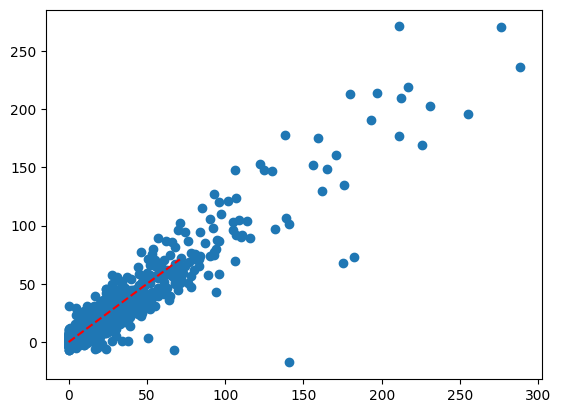

In [116]:
fig, ax = plt.subplots()
ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
ax.scatter(y_test_for_reg, y_pred_reg)

In [117]:
coef_df = pd.DataFrame({"Feature": X_train.columns, "Coefficient": reg.coef_})
sd = pd.DataFrame({"Feature": X_train.columns, "Std": X_train_scaled.std()})
coef_df = coef_df.merge(sd, on = "Feature")
coef_df["Coefficient_std"] = coef_df["Coefficient"] * coef_df["Std"]
coef_reg_sorted = coef_df.sort_values(by = "Coefficient_std", ascending=False).reset_index()

coef_reg_sorted

,index,Feature,Coefficient,Std,Coefficient_std
0,3,casos_lag_1,9.478285,1.00003,9.478574
1,2,casos_lag_2,2.987755,1.00003,2.987846
2,19,nino34ssta_lag_1,1.946244,1.00003,1.946303
3,17,nino34ssta_lag_3,1.698977,1.00003,1.699029
4,11,tmax_mean_lag_1,0.653009,1.00003,0.653029
...,...,...,...,...,...
102,38,plaquetas_lag_2,-0.437753,1.00003,-0.437766
103,9,tmax_mean_lag_3,-0.475886,1.00003,-0.475900
104,16,nino34ssta_lag_4,-0.783761,1.00003,-0.783785
105,0,casos_lag_4,-1.184560,1.00003,-1.184597


In [118]:
coef_reg_sorted["Coefficient"][32]

np.float64(0.009518569410384939)

Text(0.5, 0, 'Coefficient')

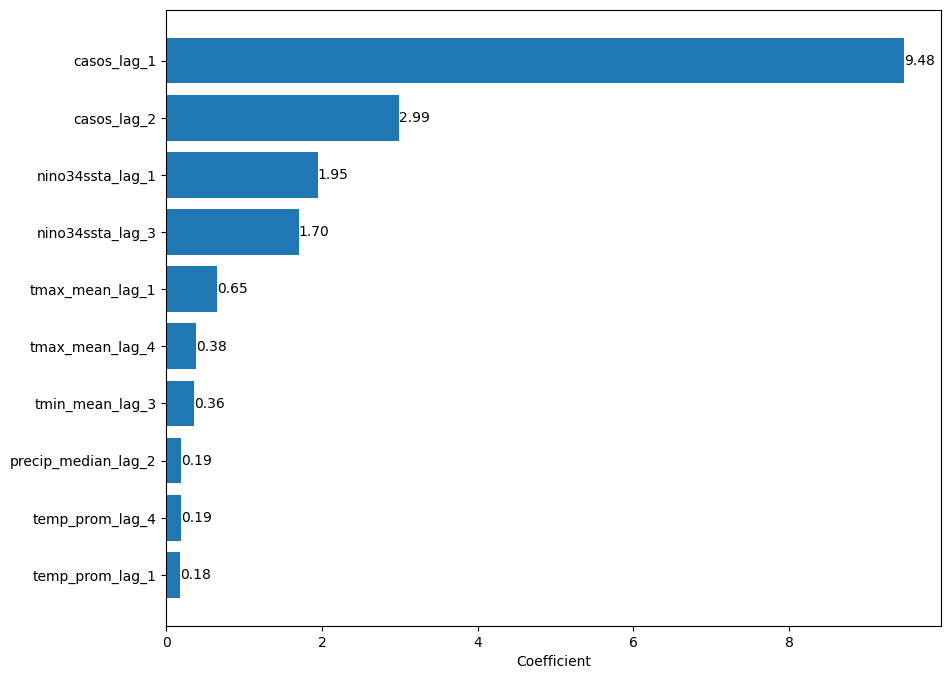

In [119]:
fig, ax = plt.subplots(figsize=(10, 8))
coef_reg_sorted = coef_df.sort_values(by = "Coefficient_std", ascending=True)
ax.barh(coef_reg_sorted["Feature"].tail(10), coef_reg_sorted["Coefficient_std"].tail(10))
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Coefficient")

### Random forest

In [120]:
rf = RandomForestRegressor(oob_score=True)

param_grid_rf = {
    'max_depth': [5],
    'min_samples_split': [10],
    'ccp_alpha': [0], 
    "criterion": ["squared_error"]
}

# param_grid_rf = {
#     'max_depth': [5, 6, 7, 8],
#     'min_samples_split': [10, 100, 500],
#     'ccp_alpha': [0, 1 /  10**5, 1 / 10**4, 1 / 10**3, 0.01, 0.1, 1, 10], 
#     "criterion": ["squared_error", "absolute_error"]
# }

grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv = 5, n_jobs=-1, verbose=10)
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ob_score=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': [0], 'criterion': ['squared_error'], 'max_depth': [5], 'min_samples_split': [10]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [121]:
# joblib.dump(grid_rf, "../models/cases_rf.pkl")

In [122]:
y_pred_rf = grid_rf.predict(X_test_for_reg)

In [123]:
results_rf = pd.DataFrame({
    'actual': y_test_for_reg,   
    'pred': y_pred_rf, 
    "week_canton": val_test["week_canton"].values
})

results_rf.to_csv('../../data/model_results/results_cases_rf_inmediato.csv')

In [124]:
mae_rf = mean_absolute_error(y_test_for_reg, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test_for_reg, y_pred_rf)

In [125]:
print(f"""MAE rf: {round(mae_rf, 3)}
RMSE rf: {round(rmse_rf, 3)}
      """)

MAE rf: 1.849
RMSE rf: 5.194
      


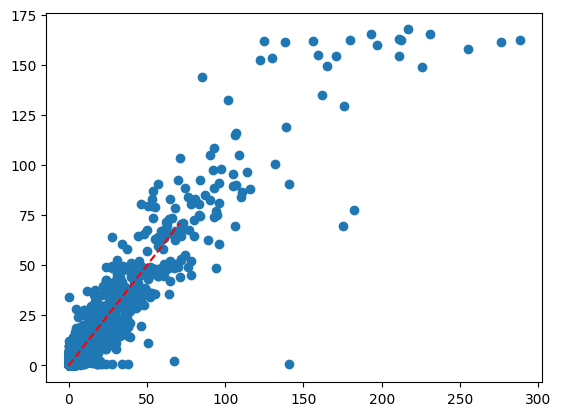

In [126]:
fig, ax = plt.subplots()
ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
ax.scatter(y_test_for_reg, y_pred_rf)

In [127]:
imp_rf_df = pd.DataFrame({"Feature": X_train.columns, "Importance": grid_rf.best_estimator_.feature_importances_})
imp_rf_sorted = imp_rf_df.sort_values(by = "Importance", ascending=False)

imp_rf_sorted

,Feature,Importance
3,casos_lag_1,0.962524
2,casos_lag_2,0.007593
1,casos_lag_3,0.002346
98,precip_median_lag_2,0.001705
87,precip_total_lag_1,0.001702
...,...,...
76,suspension_de_agua_lag_4,0.000000
101,precip_min_lag_3,0.000000
100,precip_min_lag_4,0.000000
103,precip_min_lag_1,0.000000


Text(0.5, 0, 'Importance')

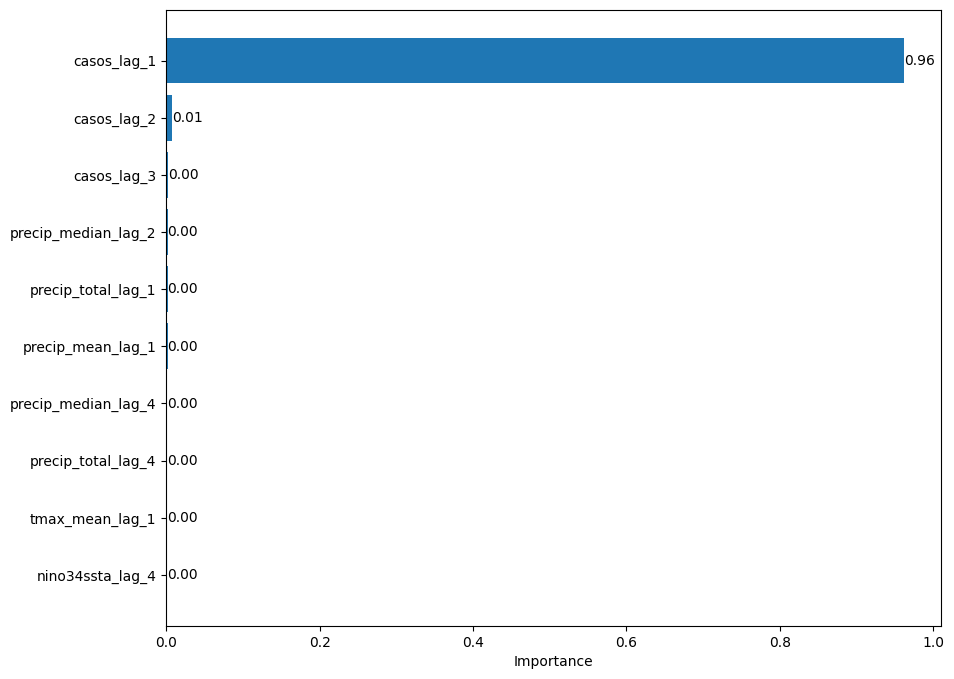

In [128]:
fig, ax = plt.subplots(figsize=(10, 8))
imp_rf_sorted = imp_rf_df.sort_values(by = "Importance", ascending=True)
ax.barh(imp_rf_sorted["Feature"].tail(10), imp_rf_sorted["Importance"].tail(10))
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Importance")

# XGBoost

In [129]:
xgb = XGBRegressor()

param_grid_xgb = {
    'max_depth': [5],
    'learning_rate': [0.1],
    'n_estimator': [50], 
    "criterion": ["friednman_mse"]
}

# param_grid_xgb = {
#     'max_depth': [5, 6, 7, 8],
#     'learning_rate': [0.1, 0.3, 0.05],
#     'n_estimator': [50, 100, 150], 
#     "criterion": ["friednman_mse", "squared_error"]
# }

grid_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid_xgb, cv = 5, n_jobs=-1, verbose=0)
grid_xgb.fit(X_train, y_train)

c:\Users\nan\OneDrive - Universidad de Costa Rica\cuenta personal\ucr pers\practica profesional\practica dengue\dengue-model\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:30:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "criterion", "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['friednman_mse'], 'learning_rate': [0.1], 'max_depth': [5], 'n_estimator': [50]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- 

In [130]:
# joblib.dump(grid_xgb, "../models/cases_xgb.pkl")

In [131]:
y_pred_xgb = grid_xgb.predict(X_test_for_reg)

In [132]:
results_xgb = pd.DataFrame({
    'actual': y_test_for_reg,   
    'pred': y_pred_xgb, 
    "week_canton": val_test["week_canton"].values
})

results_xgb.to_csv('../../data/model_results/results_cases_xgb_inmediato.csv')

In [133]:
mae_xgb = mean_absolute_error(y_test_for_reg, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test_for_reg, y_pred_xgb)

In [134]:
print(f"""MAE xgb: {round(mae_xgb, 3)}
RMSE xgb: {round(rmse_xgb, 3)}
      """)

MAE xgb: 1.913
RMSE xgb: 5.26
      


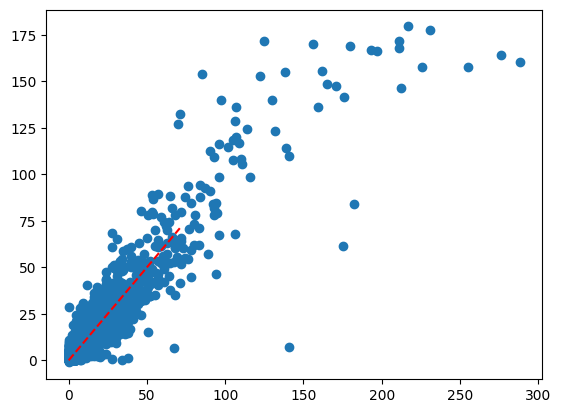

In [135]:
fig, ax = plt.subplots()
ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
ax.scatter(y_test_for_reg, y_pred_xgb)

In [136]:
imp_xgb_df = pd.DataFrame({"Feature": X_train.columns, "Importance": grid_xgb.best_estimator_.feature_importances_})
imp_xgb_sorted = imp_xgb_df.sort_values(by = "Importance", ascending=False)

imp_xgb_sorted

,Feature,Importance
3,casos_lag_1,0.552659
2,casos_lag_2,0.027259
23,temp_prom_lag_1,0.021049
98,precip_median_lag_2,0.018975
39,plaquetas_lag_1,0.018103
...,...,...
79,suspension_de_agua_lag_1,0.000000
95,precip_mean_lag_1,0.000000
92,precip_mean_lag_4,0.000000
93,precip_mean_lag_3,0.000000


Text(0.5, 0, 'Importance')

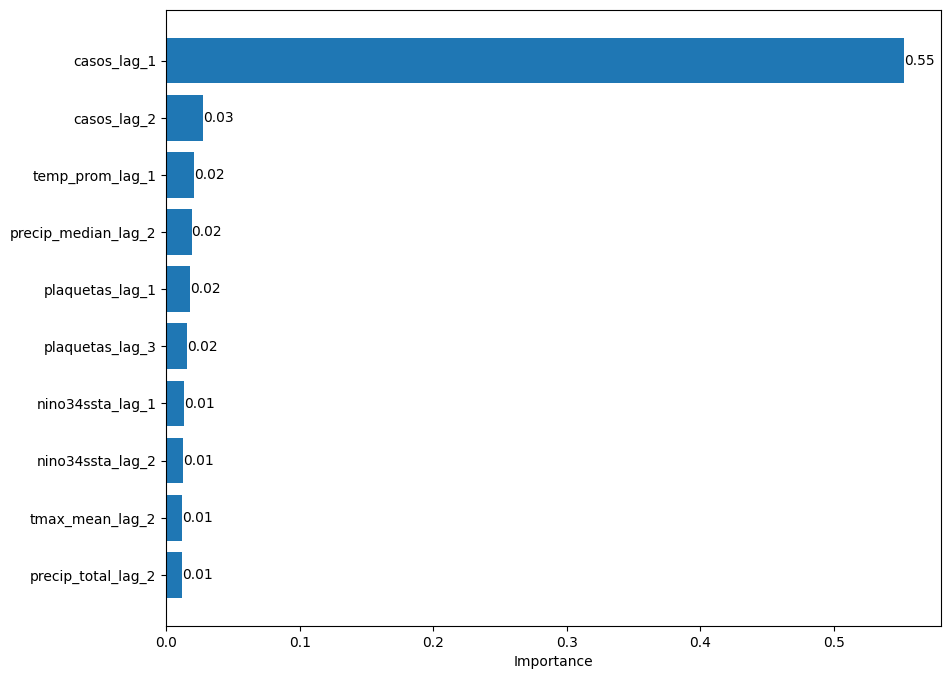

In [137]:
fig, ax = plt.subplots(figsize=(10, 8))
imp_xgb_sorted = imp_xgb_df.sort_values(by = "Importance", ascending=True)
ax.barh(imp_xgb_sorted["Feature"].tail(10), imp_xgb_sorted["Importance"].tail(10))
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Importance")

In [138]:
# REMEMBER TO RUN THE CODE WITHOUT URB DUMMIES

In [139]:
# dtrain = xgb.DMatrix(X_train, y_train, enable_categorical=True)
# dval = xgb.DMatrix(X_val, y_val, enable_categorical=True)
# dtest = xgb.DMatrix(X_test, y_test, enable_categorical=True)

In [140]:
# params = {"objective": "reg:squarederror", "tree_method": "hist"}

In [141]:
# n = 100
# xgb_model = xgb.train(
#    params=params,
#    dtrain=dtrain,
#    num_boost_round=n,
#    evals=[(dtrain, "train"), (dval, "validation")],
#    verbose_eval=10, 
#    early_stopping_rounds=50
# )

In [142]:
# xgb_preds = xgb_model.predict(dtest)

In [143]:
# fig, ax = plt.subplots()
# ax.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
# ax.scatter(y_test, xgb_preds)

In [144]:
# mae_xgb = mean_absolute_error(y_test, xgb_preds)
# rmse_xgb = root_mean_squared_error(y_test, xgb_preds)

# print(f"""MAE xgb: {round(mae_xgb, 3)}
# RMSE xgb: {round(rmse_xgb, 3)}
#       """)

In [145]:
# importance_xgb = xgb_model.get_score(importance_type="weight")
# importance_xgb_df = pd.DataFrame({"Feature": list(importance_xgb.keys()), "Importance": list(importance_xgb.values())})
# importance_xgb_sorted = importance_xgb_df.sort_values(by = "Importance", ascending=False) 
# importance_xgb_sorted.head(10)

In [146]:
# xgb.plot_importance(xgb_model, max_num_features=10, importance_type="weight")